# 00 - Setup check

**Run this notebook once, from top to bottom, before the workshop starts.**

In a few seconds it checks that your installation is complete, that the
interactive plots work, and that the measurement data sits in the right
place. If everything here is green, the other notebooks will run too.

Menu: **Run -> Run All Cells**

## 1. Packages, file formats and data

In [1]:
# Runs check_setup.py - the same thing as 'pixi run check' in the terminal.
import runpy
from pathlib import Path

script = Path.cwd().parent / "check_setup.py"
try:
    runpy.run_path(str(script), run_name="__main__")
except SystemExit:
    pass  # the script exits with an error code when something is missing

Setup check: STEM Data Analysis Workshop

1. Packages
-----------
  [ok] Python                   3.12.13
  [ok] hyperspy                 2.4.0
  [ok] exspy                    0.3.2
  [ok] rosettasciio             0.14.0
  [ok] numpy                    2.4.6
  [ok] scipy                    1.18.0
  [ok] matplotlib               3.10.9
  [ok] ipympl                   0.10.0
  [ok] hyperspy-gui-ipywidgets  2.1.1

2. dm3/dm4 reader
-----------------
  [ok] .dm3 and .dm4 can be read

3. EELS/EDX signal types (exspy)
--------------------------------
  [ok] EELS     -> EELSSpectrum
  [ok] EDS_TEM  -> EDSTEMSpectrum

4. GOSH database (for EELS edge models, ~42 MB)
-----------------------------------------------
  Downloaded from Zenodo the first time an EELS model is built, then
  cached permanently. Fetching it now saves Wi-Fi trouble on the day.
  [ok] GOSH database is available locally

5. Measurement data
-------------------
Data folder: C:\Users\KoegelMarco\OneDrive - NMI\PycharmProjects

## 2. Interactive plots

After running the next cell a **sine curve** must appear, and you must be
able to zoom and pan it with the mouse (toolbar to the left of the plot).

- Nothing appears, or just an empty box -> replace `%matplotlib widget`
  with `%matplotlib inline` and restart the kernel (menu: Kernel ->
  Restart Kernel). The notebooks still work, just without zooming.

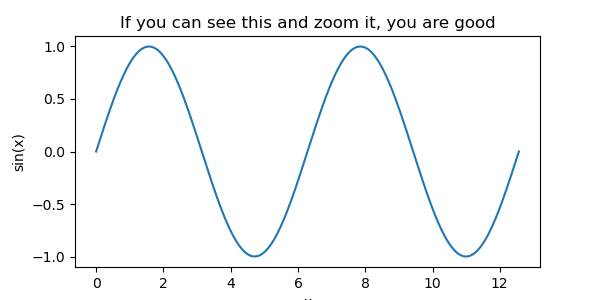

In [2]:
%matplotlib widget
import matplotlib
import numpy as np
import matplotlib.pyplot as plt

# If a plot ever fails to appear, these two lines say why.
print("backend    :", matplotlib.get_backend())
print("interactive:", plt.isinteractive())
# matplotlib reports this either as "widget" or as the full module path,
# depending on version - accept both.
INTERACTIVE_BACKENDS = ("ipympl", "widget", "nbagg")
if not any(k in matplotlib.get_backend().lower() for k in INTERACTIVE_BACKENDS):
    print()
    print("[WARNING] The interactive backend is NOT active, so figures will not")
    print("          appear by themselves. Restart the kernel and run this notebook")
    print("          first, or switch every notebook to %matplotlib inline.")
elif not plt.isinteractive():
    print()
    print("[WARNING] Interactive mode is off - figures will not appear by themselves.")
    print("          Run plt.ion() once, or restart the kernel.")
print()

x = np.linspace(0, 4 * np.pi, 400)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(x, np.sin(x))
ax.set_xlabel("x")
ax.set_ylabel("sin(x)")
ax.set_title("If you can see this and zoom it, you are good")
plt.show()

## 3. HyperSpy widgets

The next cell must show **sliders and input fields**. You need these later
for `m.gui()` when fitting models.

If you only get text instead of sliders, use the code variant in the
analysis notebooks instead of the interactive one - both sit side by side
everywhere.

In [3]:
import numpy as np
import hyperspy.api as hs
import exspy

s = hs.signals.Signal1D(np.random.rand(20, 20, 100))
s.axes_manager[-1].name = "Energy"
s.axes_manager[-1].units = "eV"
s.axes_manager.gui()

The widget matplotlib backend is not compatible with the traitsui GUI elements. For more information, read https://hyperspy.readthedocs.io/en/stable/user_guide/basic_usage.html#possible-warnings-when-importing-hyperspy.


## Done?

- Section 1 says **"Everything ready"** -> continue with `01_EELS_modeling.ipynb`
- **Data** is missing -> see the README, section "Measurement data"
- **Packages** are missing -> you most likely did not start this notebook
  through `pixi run lab`. Close JupyterLab and restart it with that command.